In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)


I0000 00:00:1774512206.983676 1788730 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774512209.311129 1788730 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
GPU available: False


E0000 00:00:1774512210.010186 1788730 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


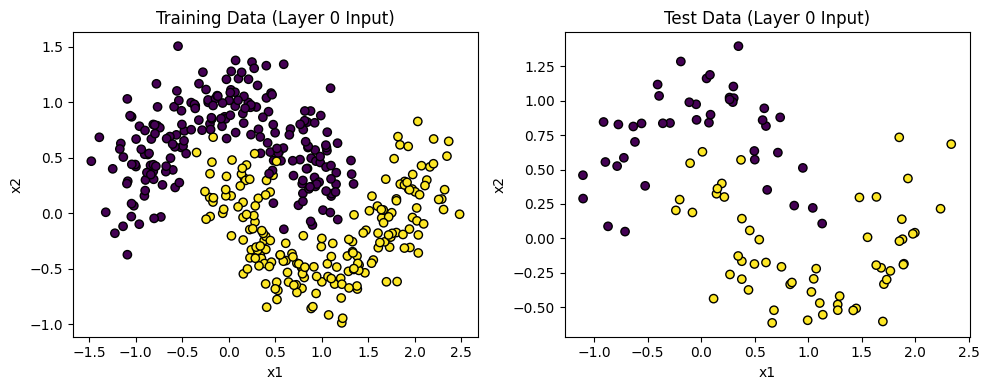

X_train: (400, 2) y_train: (400, 1)
X_test : (100, 2) y_test : (100, 1)


In [3]:
def load_data(n_samples=500, noise=0.2, test_size=0.2, random_state=42, show_plot=True):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # y reshape to (m,1) for Keras binary classification
    y_train = y_train.reshape(-1, 1).astype(np.float32)
    y_test  = y_test.reshape(-1, 1).astype(np.float32)

    X_train = X_train.astype(np.float32)
    X_test  = X_test.astype(np.float32)

    if show_plot:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train[:, 0], cmap="viridis", edgecolors="k")
        plt.title("Training Data (Layer 0 Input)")
        plt.xlabel("x1"); plt.ylabel("x2")

        plt.subplot(1, 2, 2)
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test[:, 0], cmap="viridis", edgecolors="k")
        plt.title("Test Data (Layer 0 Input)")
        plt.xlabel("x1"); plt.ylabel("x2")

        plt.tight_layout()
        plt.show()

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = load_data(show_plot=True)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)


In [4]:
def build_model(n_h=5):
    """
    Architecture (for comparison with your NumPy version):
      Layer 0 (Input): 2 features
      Layer 1 (Hidden): Dense(2 -> n_h) + tanh
      Layer 2 (Output): Dense(n_h -> 1) -> logits

    Train with:
      BinaryCrossentropy(from_logits=True)
    Predict proba with:
      sigmoid(logits)
    """
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(2,), name="Layer0_Input"),
        tf.keras.layers.Dense(n_h, activation="tanh", name="Layer1_Dense_Tanh"),
        tf.keras.layers.Dense(1, activation=None, name="Layer2_Dense_Logits"),
    ])
    return model

model = build_model(n_h=5)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Layer1_Dense_Tanh (Dense)       │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer2_Dense_Logits (Dense)     │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21 (84.00 B)

 Trainable params: 21 (84.00 B)

 Non-trainable params: 0 (0.00 B)

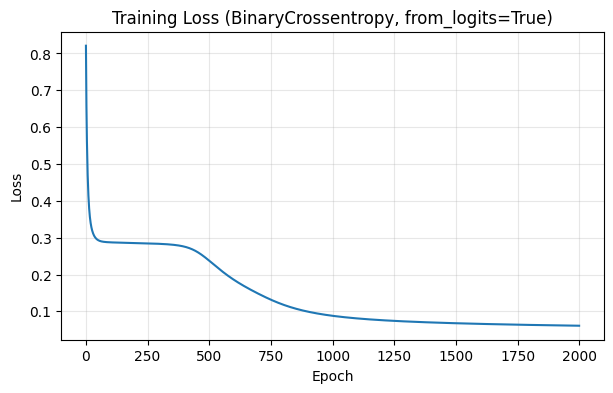

In [5]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="acc", threshold=0.0)]  # threshold on logits=0
)

history = model.fit(
    X_train, y_train,
    epochs=2000,
    batch_size=len(X_train),   # 全量 batch，行为更接近你手写版 (full-batch GD)
    verbose=0                  # 0=安静；你也可以改成 1 看进度条
)

# Plot loss curve
plt.figure(figsize=(7,4))
plt.plot(history.history["loss"])
plt.title("Training Loss (BinaryCrossentropy, from_logits=True)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()